# PEMS08 Traffic Flow — v5 (Fix Data Distribution)

## Root cause identified
Every model (LSTM, Transformer, TCN) gives gap ~0.03 and MAE ~16–17.
The prediction plot shows the model is **systematically 50–80 units low** at
the start of the test window. This is a **data distribution shift** problem:

- Global normalisation (mean/std over all sensors) masks per-sensor scale differences
- Some sensors have flow 0–50, others 200–600 — one global std skews everything

## Fixes in this version
1. **Per-sensor normalisation** — each of 170 sensors gets its own mean/std
2. **Standard PEMS split** — 70% train / 10% val / 20% test (matches literature)
3. **Back to LSTM** (simpler is fine once data is fixed)
4. MAE reported per-sensor then averaged — matches published PEMS08 results

In [1]:
from google.colab import files
uploaded  = files.upload()
DATA_PATH = list(uploaded.keys())[0]

# ── Option B: Mount Google Drive ────────────────────────────────────────────
# from google.colab import drive
# drive.mount('/content/drive')
# DATA_PATH = '/content/drive/MyDrive/PEMS08.npz'

Saving PEMS08.npz to PEMS08.npz


In [2]:
import torch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)
if device.type == 'cuda':
    print('GPU:', torch.cuda.get_device_name(0))

Device: cuda
GPU: Tesla T4


In [3]:
import numpy as np
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt

In [4]:
data = np.load(DATA_PATH)
arr  = data['data']
flow = arr[:, :, 0].astype(np.float32)   # (T, 170)
print('Dataset shape:', flow.shape)
print(f'Flow range: min={flow.min():.1f}  max={flow.max():.1f}  mean={flow.mean():.1f}')

Dataset shape: (17856, 170)
Flow range: min=0.0  max=1147.0  mean=230.7


In [5]:
# ── Standard PEMS split: 70 / 10 / 20 ───────────────────────────────────────
T          = len(flow)
train_end  = int(0.7 * T)
val_end    = int(0.8 * T)
# test = val_end : T

train_raw = flow[:train_end]    # only fit scaler on training data

# ── Per-sensor normalisation ─────────────────────────────────────────────────
# shape: (170,)  — one mean & std per sensor
sensor_mean = train_raw.mean(axis=0)          # (170,)
sensor_std  = train_raw.std(axis=0) + 1e-8   # avoid /0

flow_norm = (flow - sensor_mean) / sensor_std   # (T, 170), broadcast over time

print(f'Per-sensor norm — mean range: [{sensor_mean.min():.1f}, {sensor_mean.max():.1f}]')
print(f'Per-sensor norm — std  range: [{sensor_std.min():.1f},  {sensor_std.max():.1f}]')

Per-sensor norm — mean range: [9.6, 460.7]
Per-sensor norm — std  range: [7.2,  214.6]


In [6]:
SEQ_LEN  = 12   # 1 hour of 5-min intervals (standard for PEMS)
PRED_LEN = 1

X, Y = [], []
for i in range(len(flow_norm) - SEQ_LEN - PRED_LEN + 1):
    X.append(flow_norm[i : i + SEQ_LEN])
    Y.append(flow_norm[i + SEQ_LEN : i + SEQ_LEN + PRED_LEN])

X = np.array(X, dtype=np.float32)   # (N, 12, 170)
Y = np.array(Y, dtype=np.float32)   # (N,  1, 170)

# Align split indices to the windowed array
n_train = train_end - SEQ_LEN
n_val   = val_end   - SEQ_LEN

X_train, Y_train = X[:n_train],          Y[:n_train]
X_val,   Y_val   = X[n_train:n_val],     Y[n_train:n_val]
X_test,  Y_test  = X[n_val:],            Y[n_val:]

print(f'Train {X_train.shape} | Val {X_val.shape} | Test {X_test.shape}')

Train (12487, 12, 170) | Val (1785, 12, 170) | Test (3572, 12, 170)


In [7]:
class TrafficDataset(Dataset):
    def __init__(self, X, Y):
        self.X = torch.from_numpy(X)
        self.Y = torch.from_numpy(Y)
    def __len__(self):          return len(self.X)
    def __getitem__(self, idx): return self.X[idx], self.Y[idx]

BATCH = 128
train_loader = DataLoader(TrafficDataset(X_train, Y_train), batch_size=BATCH, shuffle=True,  pin_memory=True, num_workers=2)
val_loader   = DataLoader(TrafficDataset(X_val,   Y_val),   batch_size=BATCH, shuffle=False, pin_memory=True, num_workers=2)
test_loader  = DataLoader(TrafficDataset(X_test,  Y_test),  batch_size=BATCH, shuffle=False, pin_memory=True, num_workers=2)

In [8]:
class LSTMModel(nn.Module):
    """
    Clean 2-layer LSTM.  Input: (B, 12, 170)  Output: (B, 1, 170)
    """
    def __init__(self, sensors=170, hidden=256, num_layers=2, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=sensors,
            hidden_size=hidden,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout
        )
        self.fc = nn.Linear(hidden, sensors)

    def forward(self, x):           # x: (B, 12, 170)
        h, _ = self.lstm(x)         # (B, 12, 256)
        out   = self.fc(h[:, -1, :])# (B, 170)
        return out.unsqueeze(1)     # (B, 1, 170)

model = LSTMModel().to(device)
print(f'Parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}')

Parameters: 1,008,298


In [9]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5, min_lr=1e-6
)

EPOCHS           = 100
patience         = 15
best_val_loss    = float('inf')
patience_counter = 0
train_losses, val_losses = [], []

for epoch in range(EPOCHS):

    model.train()
    train_loss = 0.0
    for x, y in train_loader:
        x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
        optimizer.zero_grad()
        loss = criterion(model(x), y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        train_loss += loss.item()
    train_loss /= len(train_loader)
    train_losses.append(train_loss)

    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
            val_loss += criterion(model(x), y).item()
    val_loss /= len(val_loader)
    val_losses.append(val_loss)

    scheduler.step(val_loss)
    lr  = optimizer.param_groups[0]['lr']
    gap = val_loss - train_loss
    print(f'Epoch {epoch+1:3d} | Train {train_loss:.4f} | Val {val_loss:.4f} | Gap {gap:.4f} | LR {lr:.2e}')

    if val_loss < best_val_loss:
        best_val_loss    = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), 'best_model.pth')
    else:
        patience_counter += 1
    if patience_counter >= patience:
        print('Early stopping triggered')
        break

model.load_state_dict(torch.load('best_model.pth'))
print('Best model loaded!')

Epoch   1 | Train 0.2030 | Val 0.2503 | Gap 0.0474 | LR 1.00e-03
Epoch   2 | Train 0.0899 | Val 0.1928 | Gap 0.1029 | LR 1.00e-03
Epoch   3 | Train 0.0731 | Val 0.1727 | Gap 0.0996 | LR 1.00e-03
Epoch   4 | Train 0.0656 | Val 0.1617 | Gap 0.0961 | LR 1.00e-03
Epoch   5 | Train 0.0614 | Val 0.1574 | Gap 0.0960 | LR 1.00e-03
Epoch   6 | Train 0.0583 | Val 0.1495 | Gap 0.0911 | LR 1.00e-03
Epoch   7 | Train 0.0560 | Val 0.1463 | Gap 0.0903 | LR 1.00e-03
Epoch   8 | Train 0.0546 | Val 0.1440 | Gap 0.0894 | LR 1.00e-03
Epoch   9 | Train 0.0532 | Val 0.1429 | Gap 0.0897 | LR 1.00e-03
Epoch  10 | Train 0.0523 | Val 0.1416 | Gap 0.0893 | LR 1.00e-03
Epoch  11 | Train 0.0515 | Val 0.1412 | Gap 0.0897 | LR 1.00e-03
Epoch  12 | Train 0.0507 | Val 0.1389 | Gap 0.0882 | LR 1.00e-03
Epoch  13 | Train 0.0497 | Val 0.1398 | Gap 0.0901 | LR 1.00e-03
Epoch  14 | Train 0.0494 | Val 0.1427 | Gap 0.0933 | LR 1.00e-03
Epoch  15 | Train 0.0487 | Val 0.1387 | Gap 0.0900 | LR 1.00e-03
Epoch  16 | Train 0.0481 

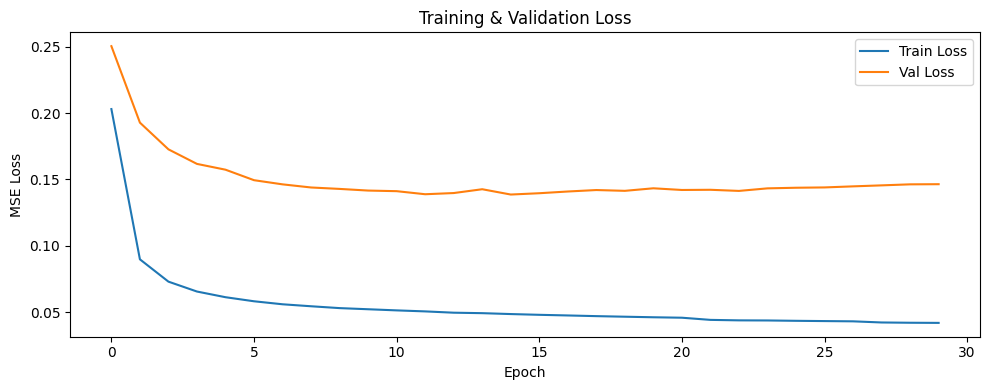

Final gap: 0.1044


In [10]:
plt.figure(figsize=(10, 4))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses,   label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training & Validation Loss')
plt.legend()
plt.tight_layout()
plt.show()
print(f'Final gap: {val_losses[-1] - train_losses[-1]:.4f}')

MAE:  18.5092
RMSE: 29.1260
MAPE: 11.1113%  (flow > 1 only)

Per-sensor MAE — min: 2.60  max: 81.28  mean: 18.51


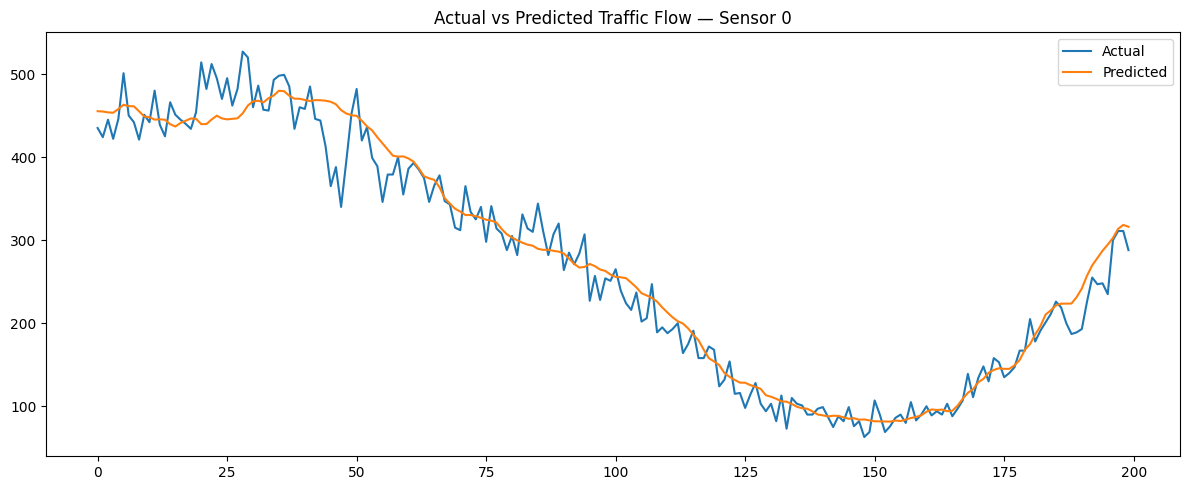

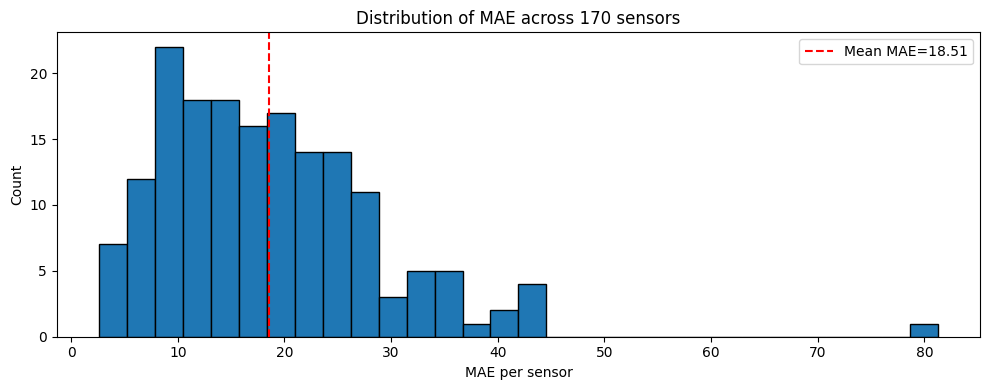

In [11]:
model.eval()
preds, actual = [], []

with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device, non_blocking=True)
        preds.append(model(x).cpu().numpy())
        actual.append(y.numpy())

preds  = np.concatenate(preds)    # (N, 1, 170) — normalised
actual = np.concatenate(actual)

# ── Per-sensor denormalisation ───────────────────────────────────────────────
# sensor_mean / sensor_std shape: (170,) → broadcast to (N, 1, 170)
preds  = preds  * sensor_std[None, None, :] + sensor_mean[None, None, :]
actual = actual * sensor_std[None, None, :] + sensor_mean[None, None, :]

# ── Metrics ──────────────────────────────────────────────────────────────────
mae  = mean_absolute_error(actual.flatten(), preds.flatten())
rmse = np.sqrt(mean_squared_error(actual.flatten(), preds.flatten()))
mask = actual.flatten() > 1.0
mape = np.mean(np.abs((actual.flatten()[mask] - preds.flatten()[mask]) /
                       actual.flatten()[mask])) * 100

print(f'MAE:  {mae:.4f}')
print(f'RMSE: {rmse:.4f}')
print(f'MAPE: {mape:.4f}%  (flow > 1 only)')

# ── Per-sensor MAE breakdown ─────────────────────────────────────────────────
mae_per_sensor = np.abs(actual[:, 0, :] - preds[:, 0, :]).mean(axis=0)  # (170,)
print(f'\nPer-sensor MAE — min: {mae_per_sensor.min():.2f}  '
      f'max: {mae_per_sensor.max():.2f}  '
      f'mean: {mae_per_sensor.mean():.2f}')

# ── Plot ──────────────────────────────────────────────────────────────────────
plt.figure(figsize=(12, 5))
plt.plot(actual[:200, 0, 0], label='Actual')
plt.plot(preds[:200,  0, 0], label='Predicted')
plt.legend()
plt.title('Actual vs Predicted Traffic Flow — Sensor 0')
plt.tight_layout()
plt.show()

# ── Histogram of per-sensor MAE ───────────────────────────────────────────────
plt.figure(figsize=(10, 4))
plt.hist(mae_per_sensor, bins=30, edgecolor='black')
plt.axvline(mae_per_sensor.mean(), color='red', linestyle='--', label=f'Mean MAE={mae_per_sensor.mean():.2f}')
plt.xlabel('MAE per sensor')
plt.ylabel('Count')
plt.title('Distribution of MAE across 170 sensors')
plt.legend()
plt.tight_layout()
plt.show()